In [9]:
'''
stringency_index	Hükümetin kısıtlama sertliği endeksi (0-100, kapanma/maske zorunluluğu vb.)
population_density	Nüfus yoğunluğu (km² başına kişi)
median_age	Medyan yaş
aged_65_older / aged_70_older	Nüfusun 65/70 yaş üstü yüzdesi
gdp_per_capita	Kişi başı GSYH
extreme_poverty	Aşırı yoksulluk oranı
cardiovasc_death_rate	Kardiyovasküler hastalık ölüm oranı
diabetes_prevalence	Diyabet yaygınlığı
female_smokers / male_smokers	Sigara içme oranları (cinsiyete göre)
handwashing_facilities	El yıkama imkanına erişim oranı
hospital_beds_per_thousand	Bin kişiye düşen hastane yatağı
life_expectancy	Ortalama yaşam beklentisi
human_development_index	İnsani gelişmişlik endeksi (HDI)
population	Toplam nüfus
'''

'\nstringency_index\tHükümetin kısıtlama sertliği endeksi (0-100, kapanma/maske zorunluluğu vb.)\npopulation_density\tNüfus yoğunluğu (km² başına kişi)\nmedian_age\tMedyan yaş\naged_65_older / aged_70_older\tNüfusun 65/70 yaş üstü yüzdesi\ngdp_per_capita\tKişi başı GSYH\nextreme_poverty\tAşırı yoksulluk oranı\ncardiovasc_death_rate\tKardiyovasküler hastalık ölüm oranı\ndiabetes_prevalence\tDiyabet yaygınlığı\nfemale_smokers / male_smokers\tSigara içme oranları (cinsiyete göre)\nhandwashing_facilities\tEl yıkama imkanına erişim oranı\nhospital_beds_per_thousand\tBin kişiye düşen hastane yatağı\nlife_expectancy\tOrtalama yaşam beklentisi\nhuman_development_index\tİnsani gelişmişlik endeksi (HDI)\npopulation\tToplam nüfus\n'

In [ ]:
#gdp_per_capita:Üretilen ekonomik değerin kişi başına düşen miktarıdır
#human_development_index:İnsani gelişmişlik değerini ölçer
#life_expectancy:Beklenen ortalama yaşam süresi
socioeconomic_coverage = df_countries.groupby('location').agg(
    toplam_satir=('date', 'size'),
    dolu_gdp_kaydi=('gdp_per_capita', 'count'),
    dolu_hdi_kaydi=('human_development_index', 'count'),
    dolu_yasam_beklentisi_kaydi=('life_expectancy', 'count')
)

socioeconomic_coverage['bos_gdp_kaydi'] = (
    socioeconomic_coverage['toplam_satir']
    - socioeconomic_coverage['dolu_gdp_kaydi']
)

socioeconomic_coverage['bos_hdi_kaydi'] = (
    socioeconomic_coverage['toplam_satir']
    - socioeconomic_coverage['dolu_hdi_kaydi']
)

socioeconomic_coverage['bos_yasam_beklentisi_kaydi'] = (
    socioeconomic_coverage['toplam_satir']
    - socioeconomic_coverage['dolu_yasam_beklentisi_kaydi']
)

print(
    socioeconomic_coverage
    .sort_values('dolu_gdp_kaydi')
    .head(20)
)

                                 toplam_satir  dolu_gdp_kaydi  dolu_hdi_kaydi  \
location                                                                        
American Samoa                           1674               0               0   
Andorra                                  1674               0            1674   
Anguilla                                 1674               0               0   
British Virgin Islands                   1674               0               0   
Bonaire Sint Eustatius and Saba          1674               0               0   
Cuba                                     1674               0            1674   
Curacao                                  1674               0               0   
Cook Islands                             1674               0               0   
Gibraltar                                1674               0               0   
Greenland                                1674               0               0   
Guam                        

In [138]:
socioeconomic_availability = pd.Series({
    'GDP bilgisi hiç olmayan konum': (
        socioeconomic_coverage['dolu_gdp_kaydi'].eq(0).sum()
    ),
    'GDP bilgisi bulunan konum': (
        socioeconomic_coverage['dolu_gdp_kaydi'].gt(0).sum()
    ),
    'HDI bilgisi hiç olmayan konum': (
        socioeconomic_coverage['dolu_hdi_kaydi'].eq(0).sum()
    ),
    'HDI bilgisi bulunan konum': (
        socioeconomic_coverage['dolu_hdi_kaydi'].gt(0).sum()
    ),
    'Yaşam beklentisi hiç olmayan konum': (
        socioeconomic_coverage['dolu_yasam_beklentisi_kaydi'].eq(0).sum()
    ),
    'Yaşam beklentisi bulunan konum': (
        socioeconomic_coverage['dolu_yasam_beklentisi_kaydi'].gt(0).sum()
    )
})

print(socioeconomic_availability)

GDP bilgisi hiç olmayan konum          44
GDP bilgisi bulunan konum             195
HDI bilgisi hiç olmayan konum          50
HDI bilgisi bulunan konum             189
Yaşam beklentisi hiç olmayan konum      6
Yaşam beklentisi bulunan konum        233
dtype: int64


In [139]:
#üçünün de olduğu konum
complete_socioeconomic_locations = socioeconomic_coverage.loc[
    socioeconomic_coverage['dolu_gdp_kaydi'].gt(0)
    & socioeconomic_coverage['dolu_hdi_kaydi'].gt(0)
    & socioeconomic_coverage['dolu_yasam_beklentisi_kaydi'].gt(0)
]

print(
    'Üç göstergesi de bulunan konum sayısı:',
    complete_socioeconomic_locations.shape[0]
)

print(complete_socioeconomic_locations.head())

Üç göstergesi de bulunan konum sayısı: 185
                     toplam_satir  dolu_gdp_kaydi  dolu_hdi_kaydi  \
location                                                            
Afghanistan                  1674            1674            1674   
Albania                      1674            1674            1674   
Algeria                      1674            1674            1674   
Angola                       1674            1674            1674   
Antigua and Barbuda          1674            1674            1674   

                     dolu_yasam_beklentisi_kaydi  bos_gdp_kaydi  \
location                                                          
Afghanistan                                 1674              0   
Albania                                     1674              0   
Algeria                                     1674              0   
Angola                                      1674              0   
Antigua and Barbuda                         1674              0   

   

In [140]:
socioeconomic_value_check = (
    df_countries.loc[
        df_countries['location'].isin(
            complete_socioeconomic_locations.index
        )
    ]
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),

        dolu_gdp_kaydi=('gdp_per_capita', 'count'),
        farkli_gdp_degeri=('gdp_per_capita', 'nunique'),
        en_dusuk_gdp=('gdp_per_capita', 'min'),
        en_yuksek_gdp=('gdp_per_capita', 'max'),

        dolu_hdi_kaydi=('human_development_index', 'count'),
        farkli_hdi_degeri=('human_development_index', 'nunique'),
        en_dusuk_hdi=('human_development_index', 'min'),
        en_yuksek_hdi=('human_development_index', 'max'),

        dolu_yasam_kaydi=('life_expectancy', 'count'),
        farkli_yasam_degeri=('life_expectancy', 'nunique'),
        en_dusuk_yasam=('life_expectancy', 'min'),
        en_yuksek_yasam=('life_expectancy', 'max')
    )
)

print(socioeconomic_value_check.head())

                     toplam_satir  dolu_gdp_kaydi  farkli_gdp_degeri  \
location                                                               
Afghanistan                  1674            1674                  1   
Albania                      1674            1674                  1   
Algeria                      1674            1674                  1   
Angola                       1674            1674                  1   
Antigua and Barbuda          1674            1674                  1   

                     en_dusuk_gdp  en_yuksek_gdp  dolu_hdi_kaydi  \
location                                                           
Afghanistan               1803.99        1803.99            1674   
Albania                  11803.43       11803.43            1674   
Algeria                  13913.84       13913.84            1674   
Angola                    5819.50        5819.50            1674   
Antigua and Barbuda      21490.94       21490.94            1674   

                  

In [141]:
socioeconomic_needs_review = socioeconomic_value_check.loc[
    # GDP kontrolleri
    (socioeconomic_value_check['dolu_gdp_kaydi']
     < socioeconomic_value_check['toplam_satir'])
    | (socioeconomic_value_check['farkli_gdp_degeri'].ne(1))
    | (socioeconomic_value_check['en_dusuk_gdp'].le(0))

    # HDI kontrolleri
    | (socioeconomic_value_check['dolu_hdi_kaydi']
       < socioeconomic_value_check['toplam_satir'])
    | (socioeconomic_value_check['farkli_hdi_degeri'].ne(1))
    | (socioeconomic_value_check['en_dusuk_hdi'].lt(0))
    | (socioeconomic_value_check['en_yuksek_hdi'].gt(1))

    # Yaşam beklentisi kontrolleri
    | (socioeconomic_value_check['dolu_yasam_kaydi']
       < socioeconomic_value_check['toplam_satir'])
    | (socioeconomic_value_check['farkli_yasam_degeri'].ne(1))
    | (socioeconomic_value_check['en_dusuk_yasam'].le(0))
]

print(socioeconomic_needs_review)

Empty DataFrame
Columns: [toplam_satir, dolu_gdp_kaydi, farkli_gdp_degeri, en_dusuk_gdp, en_yuksek_gdp, dolu_hdi_kaydi, farkli_hdi_degeri, en_dusuk_hdi, en_yuksek_hdi, dolu_yasam_kaydi, farkli_yasam_degeri, en_dusuk_yasam, en_yuksek_yasam]
Index: []


In [142]:
socioeconomic_profile = (
    df_countries.loc[
        df_countries['location'].isin(
            complete_socioeconomic_locations.index
        ),
        [
            'location',
            'gdp_per_capita',
            'human_development_index',
            'life_expectancy'
        ]
    ]
    .groupby('location', as_index=False)
    .first()
)

print(
    socioeconomic_profile
    .sort_values('gdp_per_capita', ascending=False)
    .head(15)
    .to_string(index=False)
)

            location  gdp_per_capita  human_development_index  life_expectancy
               Qatar       116935.60                     0.85            80.23
          Luxembourg        94277.96                     0.92            82.25
           Singapore        85535.38                     0.94            83.62
              Brunei        71809.25                     0.84            75.86
             Ireland        67335.29                     0.96            82.30
United Arab Emirates        67293.48                     0.89            77.97
              Kuwait        65530.54                     0.81            75.49
              Norway        64800.06                     0.96            82.40
         Switzerland        57410.17                     0.96            83.78
           Hong Kong        56054.92                     0.95            84.86
       United States        54225.45                     0.93            78.86
        Saudi Arabia        49045.41                

In [143]:
comparison_date = pd.Timestamp('2024-08-04')

gdp_death_data = (
    socioeconomic_profile
    .merge(
        df_countries.loc[
            df_countries['date'].eq(comparison_date),
            [
                'location',
                'total_deaths_per_million'
            ]
        ]
        .dropna(subset=['total_deaths_per_million']),
        on='location',
        how='inner'
    )
)

print('Karşılaştırmaya dahil edilen konum sayısı:', gdp_death_data.shape[0])

print(
    gdp_death_data[
        [
            'location',
            'gdp_per_capita',
            'total_deaths_per_million'
        ]
    ]
    .head()
    .to_string(index=False)
)

Karşılaştırmaya dahil edilen konum sayısı: 184
           location  gdp_per_capita  total_deaths_per_million
        Afghanistan         1803.99                    197.10
            Albania        11803.43                   1274.93
            Algeria        13913.84                    151.31
             Angola         5819.50                     54.36
Antigua and Barbuda        21490.94                   1572.41


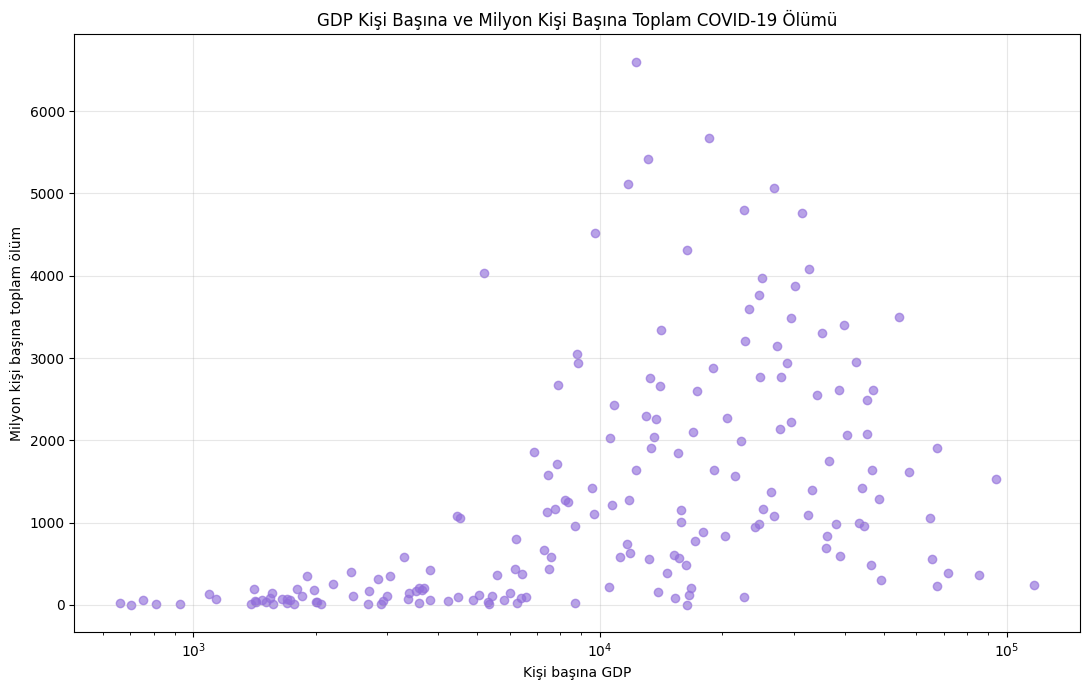

In [144]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    gdp_death_data['gdp_per_capita'],
    gdp_death_data['total_deaths_per_million'],
    color='mediumpurple',
    alpha=0.65
)

ax.set_title(
    'GDP Kişi Başına ve Milyon Kişi Başına Toplam COVID-19 Ölümü'
)
ax.set_xlabel('Kişi başına GDP')
ax.set_ylabel('Milyon kişi başına toplam ölüm')

# GDP değerleri çok geniş aralıkta olduğu için
# x eksenini logaritmik gösteriyoruz.
ax.set_xscale('log')

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

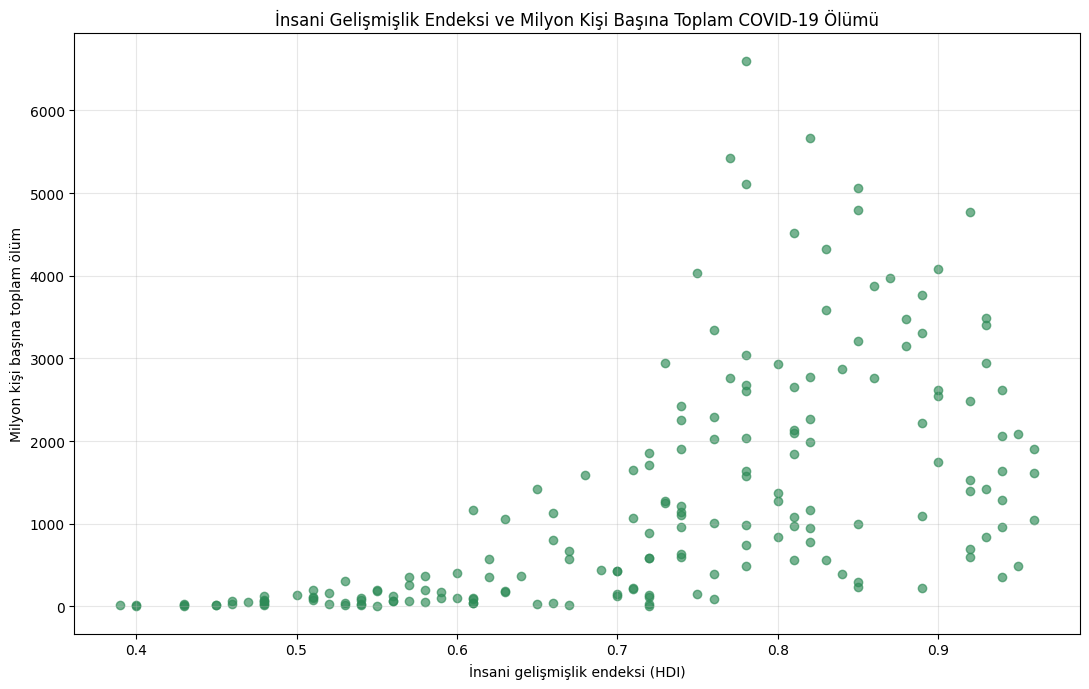

In [145]:
#HDI ile ölüm ilişkisinin incelenmesi
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    gdp_death_data['human_development_index'],
    gdp_death_data['total_deaths_per_million'],
    color='seagreen',
    alpha=0.65
)

ax.set_title(
    'İnsani Gelişmişlik Endeksi ve Milyon Kişi Başına Toplam COVID-19 Ölümü'
)
ax.set_xlabel('İnsani gelişmişlik endeksi (HDI)')
ax.set_ylabel('Milyon kişi başına toplam ölüm')

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [149]:
selected_week_vaccination = (
    weekly_vaccination_comparison[
        weekly_vaccination_comparison['hafta_baslangici']
        == pd.Timestamp('2021-09-06')
    ]
    .sort_values(['location', 'date'])
    .groupby('location', as_index=False)
    .last()
)

print(
    selected_week_vaccination[
        ['location', 'date', 'people_fully_vaccinated_per_hundred']
    ].head()
)

              location       date  people_fully_vaccinated_per_hundred
0              Albania 2021-09-12                                24.79
1               Angola 2021-09-11                                 2.69
2             Anguilla 2021-09-10                                56.61
3  Antigua and Barbuda 2021-09-10                                38.08
4            Argentina 2021-09-12                                37.07


In [150]:
#HDI ile aşı verisinin incelenmesi
hdi_vaccination_data = (
    socioeconomic_profile[
        ['location', 'human_development_index']
    ]
    .merge(
        selected_week_vaccination[
            ['location', 'people_fully_vaccinated_per_hundred']
        ],
        on='location',
        how='inner'
    )
    .dropna()
)

print('Karşılaştırılan ülke sayısı:', len(hdi_vaccination_data))
print(hdi_vaccination_data.head())

Karşılaştırılan ülke sayısı: 151
              location  human_development_index  \
0              Albania                     0.80   
1               Angola                     0.58   
2  Antigua and Barbuda                     0.78   
3            Argentina                     0.84   
4              Armenia                     0.78   

   people_fully_vaccinated_per_hundred  
0                                24.79  
1                                 2.69  
2                                38.08  
3                                37.07  
4                                 4.33  


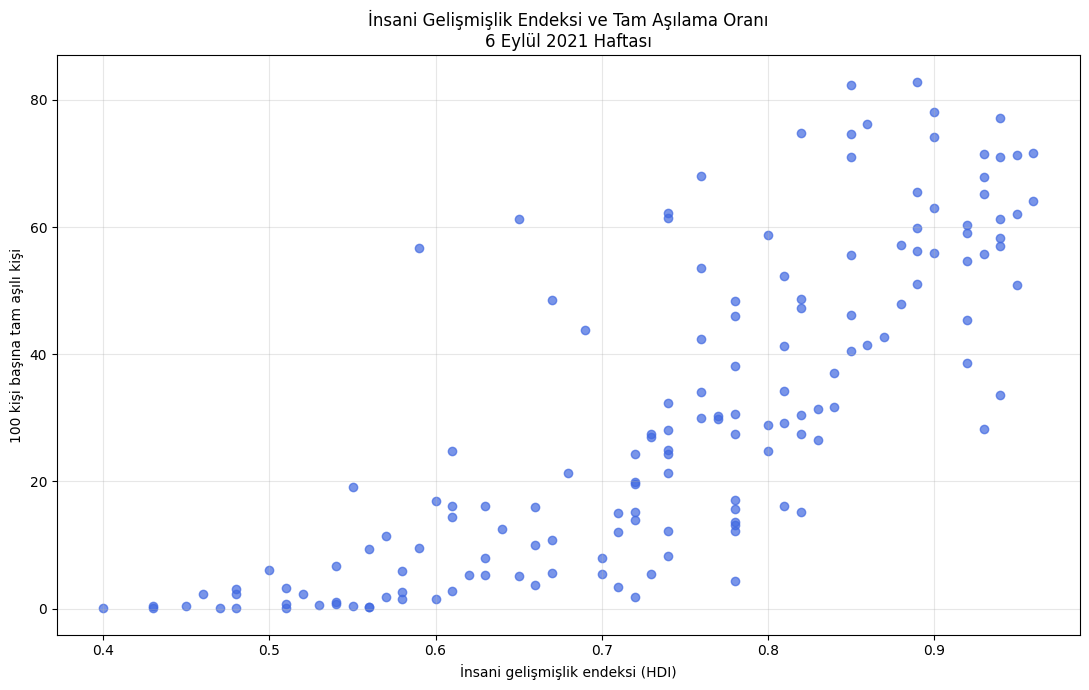

In [152]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    hdi_vaccination_data['human_development_index'],
    hdi_vaccination_data['people_fully_vaccinated_per_hundred'],
    color='royalblue',
    alpha=0.7
)

ax.set_title(
    'İnsani Gelişmişlik Endeksi ve Tam Aşılama Oranı\n'
    '6 Eylül 2021 Haftası'
)
ax.set_xlabel('İnsani gelişmişlik endeksi (HDI)')
ax.set_ylabel('100 kişi başına tam aşılı kişi')

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [154]:
#median_age:Ülkedeki ortanca yaştır.
#aged_65_older:Ülke nüfusunun kaçının 65 yaş ve üstünde olduğunu gösteriyor.
age_coverage = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),
        dolu_medyan_yas_kaydi=('median_age', 'count'),
        dolu_65_ustu_kaydi=('aged_65_older', 'count')
    )
)

age_coverage['bos_medyan_yas_kaydi'] = (
    age_coverage['toplam_satir']
    - age_coverage['dolu_medyan_yas_kaydi']
)

age_coverage['bos_65_ustu_kaydi'] = (
    age_coverage['toplam_satir']
    - age_coverage['dolu_65_ustu_kaydi']
)

print(
    age_coverage
    .sort_values('dolu_65_ustu_kaydi')
    .head(20)
)

                                 toplam_satir  dolu_medyan_yas_kaydi  \
location                                                               
American Samoa                           1674                      0   
Andorra                                  1674                      0   
Anguilla                                 1674                      0   
Bermuda                                  1674                      0   
Bonaire Sint Eustatius and Saba          1674                      0   
British Virgin Islands                   1674                      0   
Cook Islands                             1674                      0   
Cayman Islands                           1674                      0   
Dominica                                 1674                      0   
Greenland                                1674                      0   
Guernsey                                 1674                      0   
Guadeloupe                               1674                   

In [155]:
age_value_check = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),

        medyan_yas_kaydi=('median_age', 'count'),
        farkli_medyan_yas_degeri=('median_age', 'nunique'),
        en_dusuk_medyan_yas=('median_age', 'min'),
        en_yuksek_medyan_yas=('median_age', 'max'),

        yasli_nufus_kaydi=('aged_65_older', 'count'),
        farkli_65_ustu_degeri=('aged_65_older', 'nunique'),
        en_dusuk_65_ustu_orani=('aged_65_older', 'min'),
        en_yuksek_65_ustu_orani=('aged_65_older', 'max')
    )
)

print(age_value_check.head(10))

                     toplam_satir  medyan_yas_kaydi  farkli_medyan_yas_degeri  \
location                                                                        
Afghanistan                  1674              1674                         1   
Albania                      1674              1674                         1   
Algeria                      1674              1674                         1   
American Samoa               1674                 0                         0   
Andorra                      1674                 0                         0   
Angola                       1674              1674                         1   
Anguilla                     1674                 0                         0   
Antigua and Barbuda          1674              1674                         1   
Argentina                    1678              1678                         1   
Armenia                      1674              1674                         1   

                     en_dus

In [156]:
valid_age_locations = age_value_check[
    (age_value_check['medyan_yas_kaydi'] > 0)
    & (age_value_check['yasli_nufus_kaydi'] > 0)
    & (age_value_check['farkli_medyan_yas_degeri'] == 1)
    & (age_value_check['farkli_65_ustu_degeri'] == 1)
].index

age_profile = (
    df_countries[
        df_countries['location'].isin(valid_age_locations)
    ]
    .groupby('location', as_index=False)
    .agg(
        median_age=('median_age', 'first'),
        aged_65_older=('aged_65_older', 'first')
    )
)

print('Yaş profili bulunan ülke sayısı:', len(age_profile))
print(age_profile.head())

Yaş profili bulunan ülke sayısı: 192
              location  median_age  aged_65_older
0          Afghanistan        18.6           2.58
1              Albania        38.0          13.19
2              Algeria        29.1           6.21
3               Angola        16.8           2.40
4  Antigua and Barbuda        32.1           6.93


In [157]:
age_death_data = (
    age_profile
    .merge(
        df_countries[
            df_countries['date'] == pd.Timestamp('2024-08-04')
        ][
            ['location', 'total_deaths_per_million']
        ],
        on='location',
        how='inner'
    )
    .dropna()
)

print('Karşılaştırılan ülke sayısı:', len(age_death_data))
print(age_death_data.head())

Karşılaştırılan ülke sayısı: 190
              location  median_age  aged_65_older  total_deaths_per_million
0          Afghanistan        18.6           2.58                    197.10
1              Albania        38.0          13.19                   1274.93
2              Algeria        29.1           6.21                    151.31
3               Angola        16.8           2.40                     54.36
4  Antigua and Barbuda        32.1           6.93                   1572.41


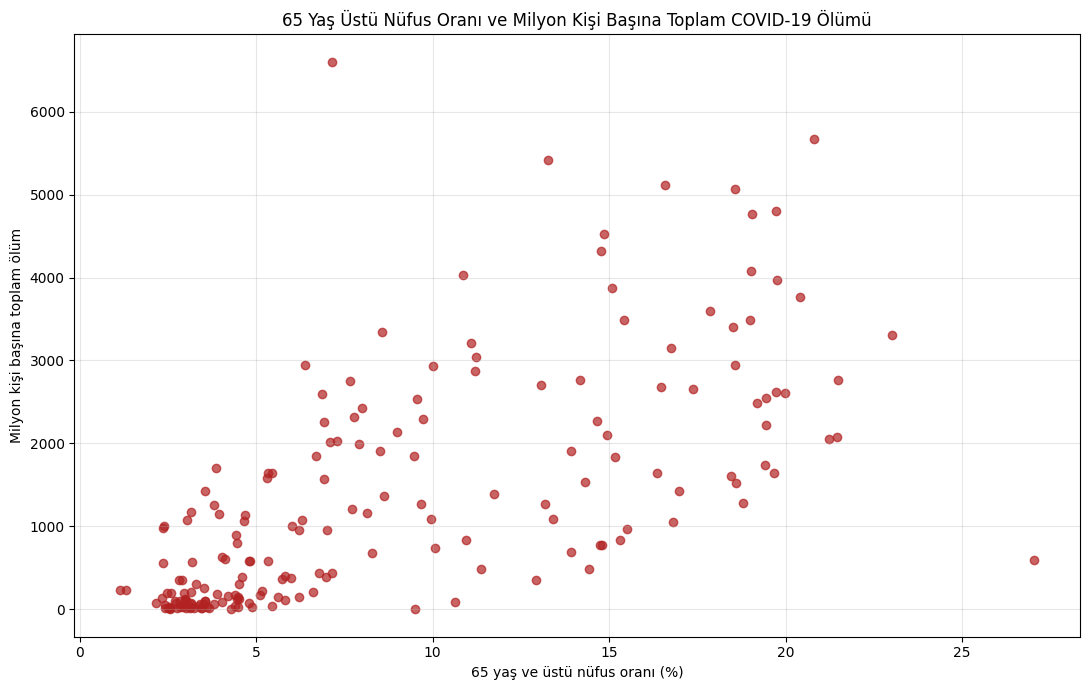

In [158]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    age_death_data['aged_65_older'],
    age_death_data['total_deaths_per_million'],
    color='firebrick',
    alpha=0.7
)

ax.set_title(
    '65 Yaş Üstü Nüfus Oranı ve Milyon Kişi Başına Toplam COVID-19 Ölümü'
)
ax.set_xlabel('65 yaş ve üstü nüfus oranı (%)')
ax.set_ylabel('Milyon kişi başına toplam ölüm')

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [159]:
correlation_65_death = (
    age_death_data['aged_65_older']
    .corr(age_death_data['total_deaths_per_million'])
)

print(
    '65 yaş üstü nüfus oranı ile milyon kişi başına toplam ölüm korelasyonu:',
    round(correlation_65_death, 3)
)

65 yaş üstü nüfus oranı ile milyon kişi başına toplam ölüm korelasyonu: 0.675


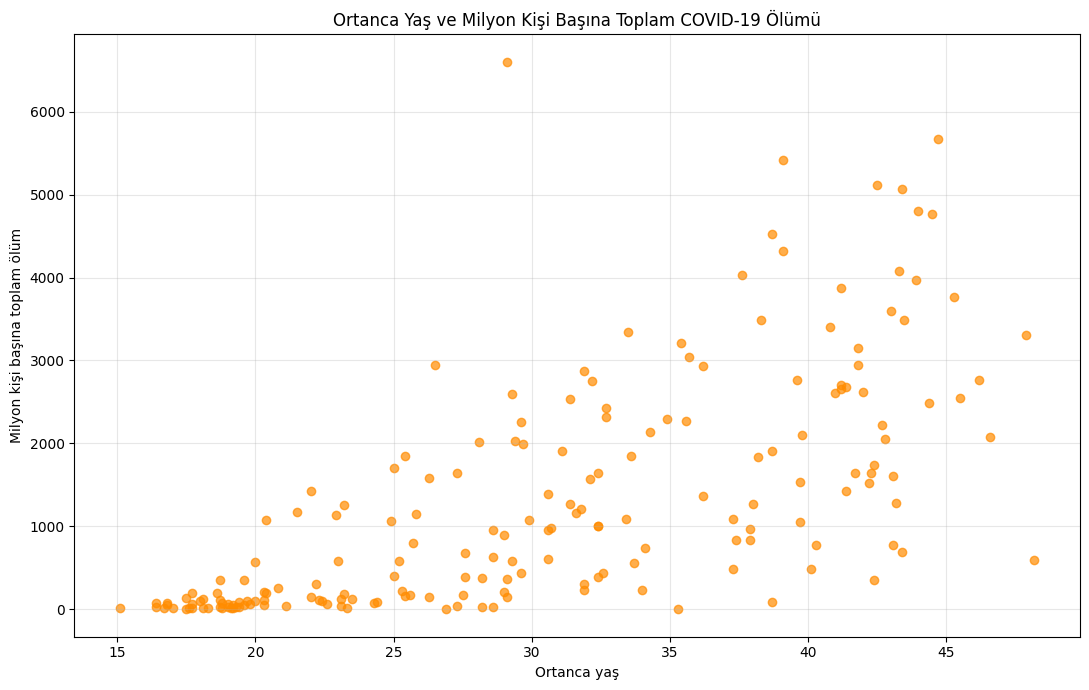

In [161]:
#median_age ile ölüm ilişkisinin incelenmesi
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    age_death_data['median_age'],
    age_death_data['total_deaths_per_million'],
    color='darkorange',
    alpha=0.7
)

ax.set_title(
    'Ortanca Yaş ve Milyon Kişi Başına Toplam COVID-19 Ölümü'
)
ax.set_xlabel('Ortanca yaş')
ax.set_ylabel('Milyon kişi başına toplam ölüm')

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [162]:
correlation_median_age_death = (
    age_death_data['median_age']
    .corr(age_death_data['total_deaths_per_million'])
)

print(
    'Ortanca yaş ile milyon kişi başına toplam ölüm korelasyonu:',
    round(correlation_median_age_death, 3)
)

Ortanca yaş ile milyon kişi başına toplam ölüm korelasyonu: 0.674


In [164]:
#life_expectancy ile ölüm oranının incelenmesi
life_expectancy_profile = (
    df_countries[
        df_countries['life_expectancy'].notna()
    ]
    .groupby('location', as_index=False)
    .agg(
        life_expectancy=('life_expectancy', 'first')
    )
)

life_expectancy_death_data = (
    life_expectancy_profile
    .merge(
        df_countries[
            df_countries['date'] == pd.Timestamp('2024-08-04')
        ][
            ['location', 'total_deaths_per_million']
        ],
        on='location',
        how='inner'
    )
    .dropna()
)

print('Karşılaştırılan ülke sayısı:', len(life_expectancy_death_data))
print(life_expectancy_death_data.head())

Karşılaştırılan ülke sayısı: 229
         location  life_expectancy  total_deaths_per_million
0     Afghanistan            64.83                    197.10
1         Albania            78.57                   1274.93
2         Algeria            76.88                    151.31
3  American Samoa            73.74                    702.99
4         Andorra            83.73                   1994.43


In [165]:
life_expectancy_profile = (
    df_countries[
        df_countries['life_expectancy'].notna()
    ]
    .groupby('location', as_index=False)
    .agg(
        life_expectancy=('life_expectancy', 'first')
    )
)

life_expectancy_death_data = (
    life_expectancy_profile
    .merge(
        df_countries[
            df_countries['date'] == pd.Timestamp('2024-08-04')
        ][
            ['location', 'total_deaths_per_million']
        ],
        on='location',
        how='inner'
    )
    .dropna()
)

print('Karşılaştırılan ülke sayısı:', len(life_expectancy_death_data))
print(life_expectancy_death_data.head())

Karşılaştırılan ülke sayısı: 229
         location  life_expectancy  total_deaths_per_million
0     Afghanistan            64.83                    197.10
1         Albania            78.57                   1274.93
2         Algeria            76.88                    151.31
3  American Samoa            73.74                    702.99
4         Andorra            83.73                   1994.43


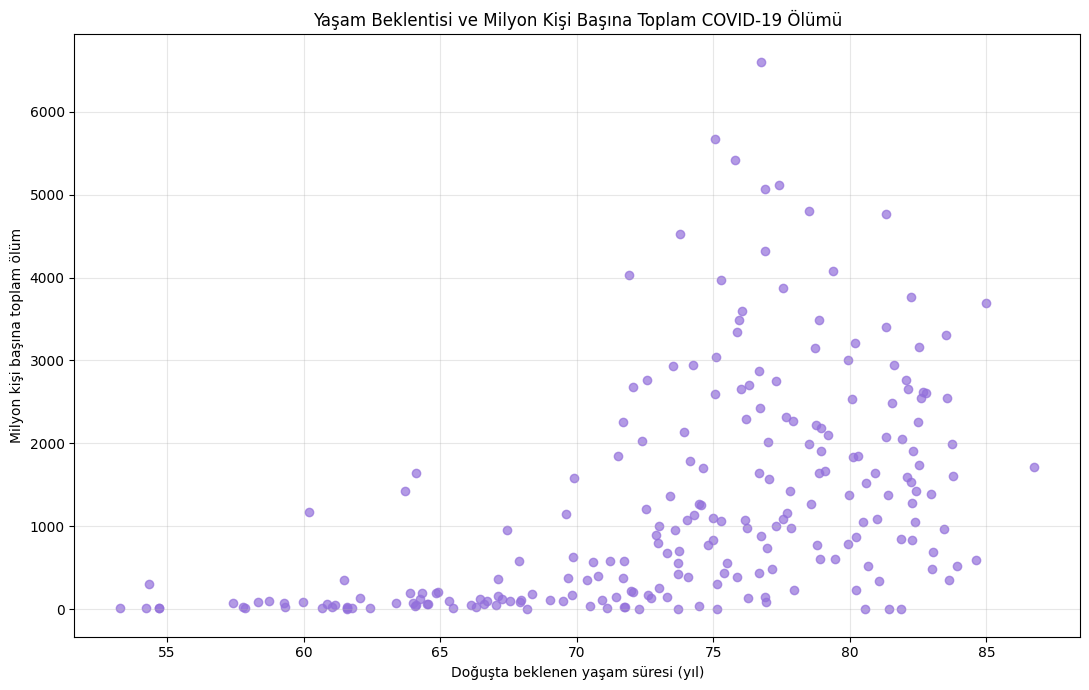

In [167]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    life_expectancy_death_data['life_expectancy'],
    life_expectancy_death_data['total_deaths_per_million'],
    color='mediumpurple',
    alpha=0.7
)

ax.set_title(
    'Yaşam Beklentisi ve Milyon Kişi Başına Toplam COVID-19 Ölümü'
)
ax.set_xlabel('Doğuşta beklenen yaşam süresi (yıl)')
ax.set_ylabel('Milyon kişi başına toplam ölüm')

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [166]:
correlation_life_expectancy_death = (
    life_expectancy_death_data['life_expectancy']
    .corr(life_expectancy_death_data['total_deaths_per_million'])
)

print(
    'Yaşam beklentisi ile milyon kişi başına toplam ölüm korelasyonu:',
    round(correlation_life_expectancy_death, 3)
)

Yaşam beklentisi ile milyon kişi başına toplam ölüm korelasyonu: 0.49


In [168]:
correlation_summary = pd.Series({
    '65 yaş üstü nüfus oranı': correlation_65_death,
    'Ortanca yaş': correlation_median_age_death,
    'Yaşam beklentisi': correlation_life_expectancy_death,
    'HDI': (
        gdp_death_data['human_development_index']
        .corr(gdp_death_data['total_deaths_per_million'])
    )
})

print(
    correlation_summary
    .sort_values(ascending=False)
    .round(3)
)

65 yaş üstü nüfus oranı    0.675
Ortanca yaş                0.674
HDI                        0.591
Yaşam beklentisi           0.490
dtype: float64


In [169]:
gdp_death_data = gdp_death_data.copy()

gdp_death_data['log_gdp_per_capita'] = np.log10(
    gdp_death_data['gdp_per_capita']
)

correlation_log_gdp_death = (
    gdp_death_data['log_gdp_per_capita']
    .corr(gdp_death_data['total_deaths_per_million'])
)

print(
    'Logaritmik kişi başına GDP ile milyon kişi başına toplam ölüm korelasyonu:',
    round(correlation_log_gdp_death, 3)
)

Logaritmik kişi başına GDP ile milyon kişi başına toplam ölüm korelasyonu: 0.491


In [170]:
correlation_summary['Logaritmik kişi başına GDP'] = (
    correlation_log_gdp_death
)

print(
    correlation_summary
    .sort_values(ascending=False)
    .round(3)
)

65 yaş üstü nüfus oranı       0.675
Ortanca yaş                   0.674
HDI                           0.591
Logaritmik kişi başına GDP    0.491
Yaşam beklentisi              0.490
dtype: float64


In [171]:
all_factors_death_data = (
    socioeconomic_profile[
        [
            'location',
            'gdp_per_capita',
            'human_development_index',
            'life_expectancy'
        ]
    ]
    .merge(
        age_profile[
            ['location', 'median_age', 'aged_65_older']
        ],
        on='location',
        how='inner'
    )
    .merge(
        df_countries[
            df_countries['date'] == pd.Timestamp('2024-08-04')
        ][
            ['location', 'total_deaths_per_million']
        ],
        on='location',
        how='inner'
    )
    .dropna()
)

print('Tüm değişkenleri bulunan ülke sayısı:', len(all_factors_death_data))

Tüm değişkenleri bulunan ülke sayısı: 180


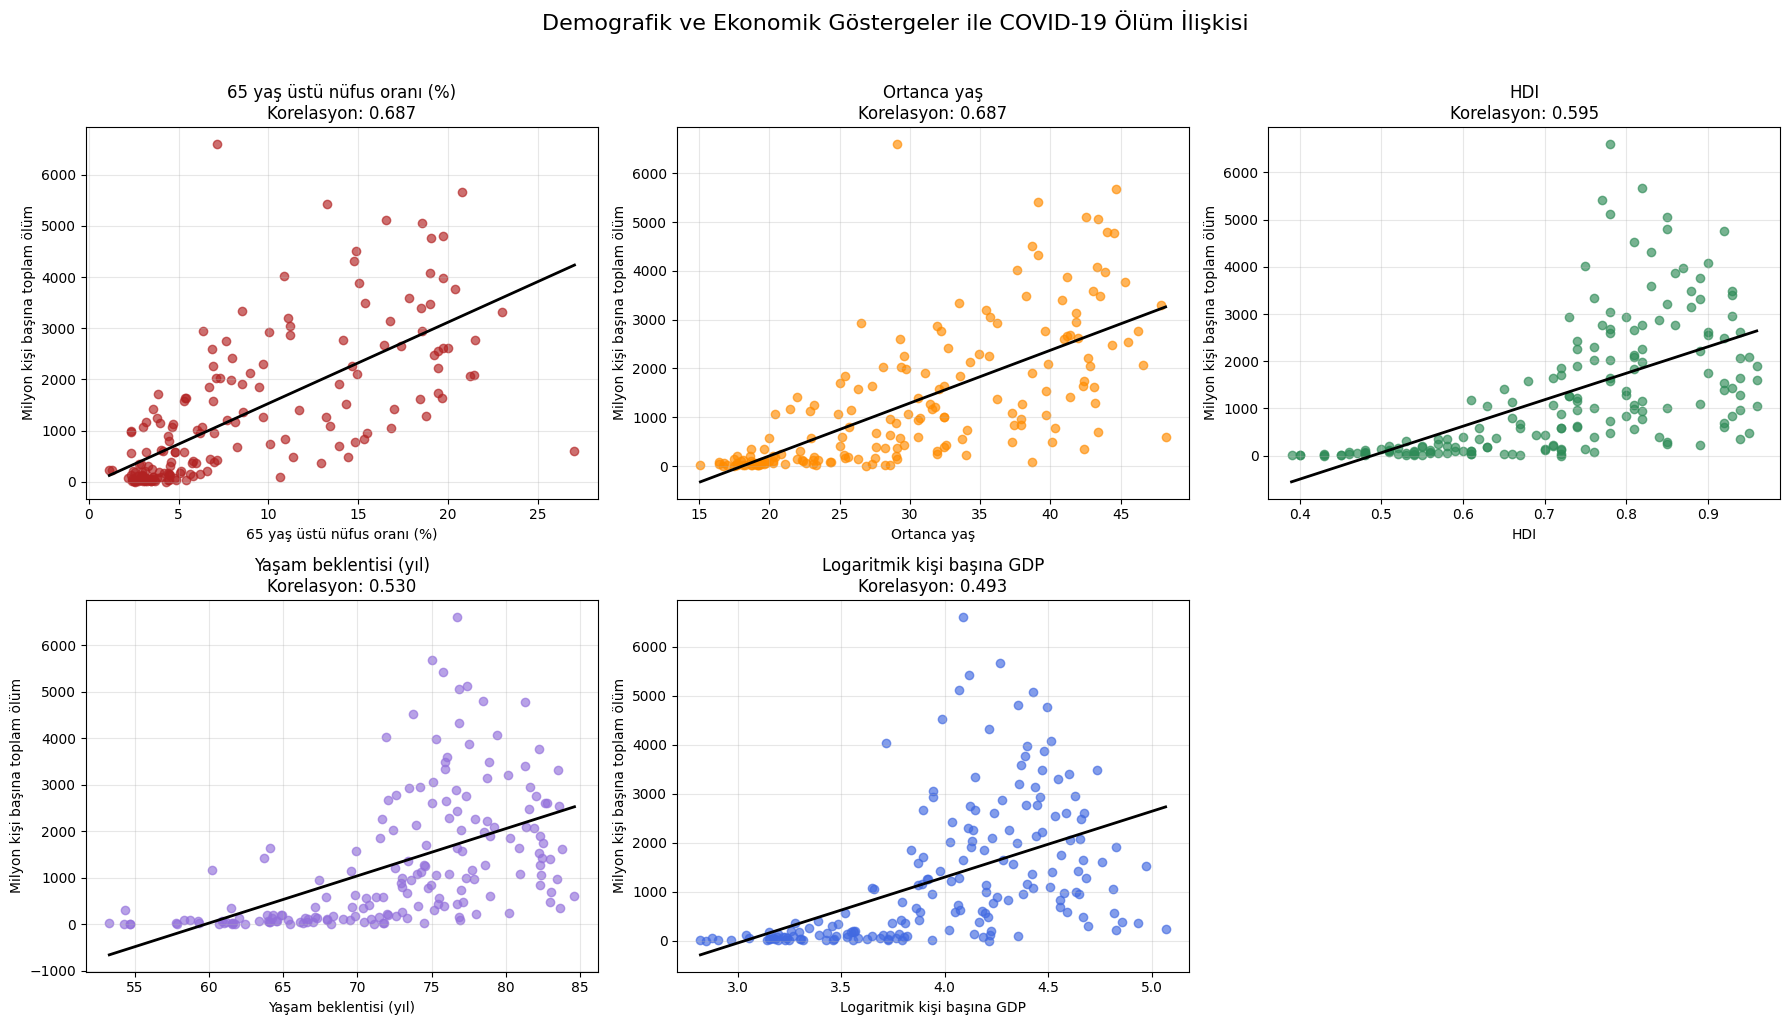

In [172]:
factors = [
    ('aged_65_older', '65 yaş üstü nüfus oranı (%)', 'firebrick'),
    ('median_age', 'Ortanca yaş', 'darkorange'),
    ('human_development_index', 'HDI', 'seagreen'),
    ('life_expectancy', 'Yaşam beklentisi (yıl)', 'mediumpurple'),
    ('log_gdp', 'Logaritmik kişi başına GDP', 'royalblue')
]

all_factors_death_data['log_gdp'] = np.log10(
    all_factors_death_data['gdp_per_capita']
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (column, label, color) in zip(axes, factors):
    x = all_factors_death_data[column]
    y = all_factors_death_data['total_deaths_per_million']

    ax.scatter(x, y, color=color, alpha=0.65)

    slope, intercept = np.polyfit(x, y, 1)
    ax.plot(
        x.sort_values(),
        slope * x.sort_values() + intercept,
        color='black',
        linewidth=2
    )

    correlation = x.corr(y)

    ax.set_title(f'{label}\nKorelasyon: {correlation:.3f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Milyon kişi başına toplam ölüm')
    ax.grid(alpha=0.3)

axes[-1].axis('off')

fig.suptitle(
    'Demografik ve Ekonomik Göstergeler ile COVID-19 Ölüm İlişkisi',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [200]:
health_risk_coverage = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),
        dolu_diyabet_kaydi=('diabetes_prevalence', 'count'),
        dolu_kardiyovaskuler_kaydi=(
            'cardiovasc_death_rate',
            'count'
        )
    )
)

health_risk_coverage['bos_diyabet_kaydi'] = (
    health_risk_coverage['toplam_satir']
    - health_risk_coverage['dolu_diyabet_kaydi']
)

health_risk_coverage['bos_kardiyovaskuler_kaydi'] = (
    health_risk_coverage['toplam_satir']
    - health_risk_coverage['dolu_kardiyovaskuler_kaydi']
)

print(
    health_risk_coverage
    .sort_values('dolu_diyabet_kaydi')
    .head(20)
)

                                 toplam_satir  dolu_diyabet_kaydi  \
location                                                            
American Samoa                           1674                   0   
Anguilla                                 1674                   0   
Bonaire Sint Eustatius and Saba          1674                   0   
Cook Islands                             1674                   0   
Gibraltar                                1674                   0   
French Guiana                            1674                   0   
Kosovo                                   1674                   0   
Macao                                     795                   0   
Isle of Man                              1674                   0   
Jersey                                   1674                   0   
Guernsey                                 1674                   0   
Guadeloupe                               1674                   0   
Falkland Islands                  

In [201]:
health_risk_value_check = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),

        diyabet_kaydi=('diabetes_prevalence', 'count'),
        farkli_diyabet_degeri=(
            'diabetes_prevalence',
            'nunique'
        ),
        en_dusuk_diyabet_orani=(
            'diabetes_prevalence',
            'min'
        ),
        en_yuksek_diyabet_orani=(
            'diabetes_prevalence',
            'max'
        ),

        kardiyovaskuler_kaydi=(
            'cardiovasc_death_rate',
            'count'
        ),
        farkli_kardiyovaskuler_deger=(
            'cardiovasc_death_rate',
            'nunique'
        ),
        en_dusuk_kardiyovaskuler_oran=(
            'cardiovasc_death_rate',
            'min'
        ),
        en_yuksek_kardiyovaskuler_oran=(
            'cardiovasc_death_rate',
            'max'
        )
    )
)

print(health_risk_value_check.head(10))

                     toplam_satir  diyabet_kaydi  farkli_diyabet_degeri  \
location                                                                  
Afghanistan                  1674           1674                      1   
Albania                      1674           1674                      1   
Algeria                      1674           1674                      1   
American Samoa               1674              0                      0   
Andorra                      1674           1674                      1   
Angola                       1674           1674                      1   
Anguilla                     1674              0                      0   
Antigua and Barbuda          1674           1674                      1   
Argentina                    1678           1678                      1   
Armenia                      1674           1674                      1   

                     en_dusuk_diyabet_orani  en_yuksek_diyabet_orani  \
location                   

In [202]:
valid_health_risk_locations = health_risk_value_check[
    (health_risk_value_check['diyabet_kaydi'] > 0)
    & (health_risk_value_check['kardiyovaskuler_kaydi'] > 0)
    & (health_risk_value_check['farkli_diyabet_degeri'] == 1)
    & (health_risk_value_check['farkli_kardiyovaskuler_deger'] == 1)
].index

health_risk_profile = (
    df_countries[
        df_countries['location'].isin(
            valid_health_risk_locations
        )
    ]
    .groupby('location', as_index=False)
    .agg(
        diabetes_prevalence=('diabetes_prevalence', 'first'),
        cardiovasc_death_rate=(
            'cardiovasc_death_rate',
            'first'
        )
    )
)

print('İki sağlık göstergesi bulunan ülke sayısı:', len(health_risk_profile))
print(health_risk_profile.head())

İki sağlık göstergesi bulunan ülke sayısı: 191
      location  diabetes_prevalence  cardiovasc_death_rate
0  Afghanistan                 9.59                 597.03
1      Albania                10.08                 304.20
2      Algeria                 6.73                 278.36
3      Andorra                 7.97                 109.14
4       Angola                 3.94                 276.04


In [203]:
health_risk_death_data = (
    health_risk_profile
    .merge(
        df_countries[
            df_countries['date'] == pd.Timestamp('2024-08-04')
        ][
            ['location', 'total_deaths_per_million']
        ],
        on='location',
        how='inner'
    )
    .dropna()
)

print('Karşılaştırılan ülke sayısı:', len(health_risk_death_data))
print(health_risk_death_data.head())

Karşılaştırılan ülke sayısı: 191
      location  diabetes_prevalence  cardiovasc_death_rate  \
0  Afghanistan                 9.59                 597.03   
1      Albania                10.08                 304.20   
2      Algeria                 6.73                 278.36   
3      Andorra                 7.97                 109.14   
4       Angola                 3.94                 276.04   

   total_deaths_per_million  
0                    197.10  
1                   1274.93  
2                    151.31  
3                   1994.43  
4                     54.36  


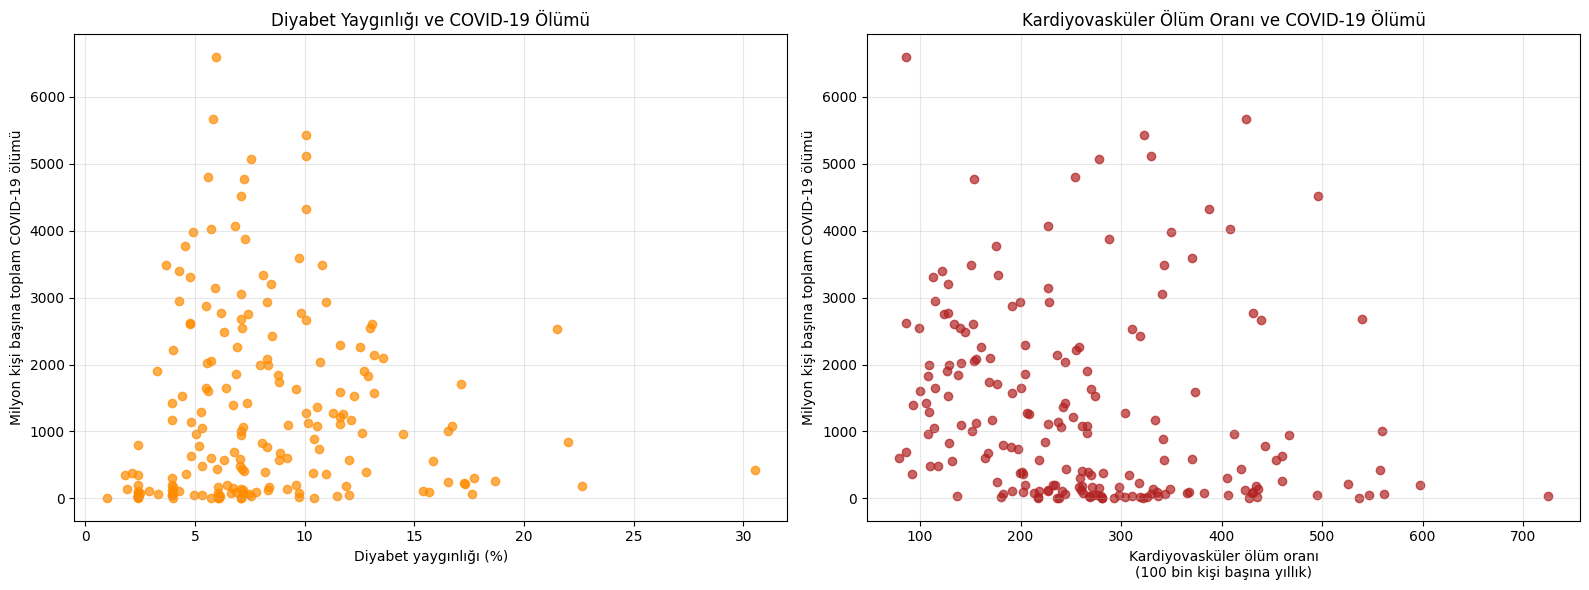

In [204]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Diyabet yaygınlığı ve COVID-19 ölümü
axes[0].scatter(
    health_risk_death_data['diabetes_prevalence'],
    health_risk_death_data['total_deaths_per_million'],
    color='darkorange',
    alpha=0.7
)

axes[0].set_title(
    'Diyabet Yaygınlığı ve COVID-19 Ölümü'
)
axes[0].set_xlabel('Diyabet yaygınlığı (%)')
axes[0].set_ylabel('Milyon kişi başına toplam COVID-19 ölümü')
axes[0].grid(alpha=0.3)

# Kardiyovasküler ölüm oranı ve COVID-19 ölümü
axes[1].scatter(
    health_risk_death_data['cardiovasc_death_rate'],
    health_risk_death_data['total_deaths_per_million'],
    color='firebrick',
    alpha=0.7
)

axes[1].set_title(
    'Kardiyovasküler Ölüm Oranı ve COVID-19 Ölümü'
)
axes[1].set_xlabel(
    'Kardiyovasküler ölüm oranı\n'
    '(100 bin kişi başına yıllık)'
)
axes[1].set_ylabel('Milyon kişi başına toplam COVID-19 ölümü')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [205]:
correlation_diabetes_death = (
    health_risk_death_data['diabetes_prevalence']
    .corr(health_risk_death_data['total_deaths_per_million'])
)

correlation_cardiovasc_death = (
    health_risk_death_data['cardiovasc_death_rate']
    .corr(health_risk_death_data['total_deaths_per_million'])
)

print(
    'Diyabet yaygınlığı ile COVID-19 ölümü korelasyonu:',
    round(correlation_diabetes_death, 3)
)

print(
    'Kardiyovasküler ölüm oranı ile COVID-19 ölümü korelasyonu:',
    round(correlation_cardiovasc_death, 3)
)

Diyabet yaygınlığı ile COVID-19 ölümü korelasyonu: 0.024
Kardiyovasküler ölüm oranı ile COVID-19 ölümü korelasyonu: -0.194


In [206]:
#population_density:Nüfus yoğunluğunun incelenmesi
density_check = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),
        dolu_nufus_yogunlugu_kaydi=(
            'population_density',
            'count'
        ),
        farkli_nufus_yogunlugu_degeri=(
            'population_density',
            'nunique'
        ),
        en_dusuk_nufus_yogunlugu=(
            'population_density',
            'min'
        ),
        en_yuksek_nufus_yogunlugu=(
            'population_density',
            'max'
        )
    )
)

density_check['bos_nufus_yogunlugu_kaydi'] = (
    density_check['toplam_satir']
    - density_check['dolu_nufus_yogunlugu_kaydi']
)

print(
    density_check
    .sort_values('dolu_nufus_yogunlugu_kaydi')
    .head(20)
)


                                 toplam_satir  dolu_nufus_yogunlugu_kaydi  \
location                                                                    
Anguilla                                 1674                           0   
Bonaire Sint Eustatius and Saba          1674                           0   
Cook Islands                             1674                           0   
Jersey                                   1674                           0   
Guernsey                                 1674                           0   
Guadeloupe                               1674                           0   
French Guiana                            1674                           0   
Falkland Islands                         1674                           0   
Reunion                                  1674                           0   
Pitcairn                                 1674                           0   
Saint Barthelemy                         1674                           0   

In [207]:
valid_density_locations = density_check[
    (density_check['dolu_nufus_yogunlugu_kaydi'] > 0)
    & (density_check['farkli_nufus_yogunlugu_degeri'] == 1)
    & (density_check['en_dusuk_nufus_yogunlugu'] > 0)
].index

density_profile = (
    df_countries[
        df_countries['location'].isin(
            valid_density_locations
        )
    ]
    .groupby('location', as_index=False)
    .agg(
        population_density=('population_density', 'first')
    )
)

density_death_data = (
    density_profile
    .merge(
        df_countries[
            df_countries['date'] == pd.Timestamp('2024-08-04')
        ][
            ['location', 'total_deaths_per_million']
        ],
        on='location',
        how='inner'
    )
    .dropna()
)

print('Karşılaştırılan ülke sayısı:', len(density_death_data))
print(density_death_data.head())

Karşılaştırılan ülke sayısı: 212
         location  population_density  total_deaths_per_million
0     Afghanistan               54.42                    197.10
1         Albania              104.87                   1274.93
2         Algeria               17.35                    151.31
3  American Samoa              278.20                    702.99
4         Andorra              163.76                   1994.43


In [208]:
correlation_density_death = (
    np.log10(density_death_data['population_density'])
    .corr(density_death_data['total_deaths_per_million'])
)

print(
    'Logaritmik nüfus yoğunluğu ile COVID-19 ölümü korelasyonu:',
    round(correlation_density_death, 3)
)

Logaritmik nüfus yoğunluğu ile COVID-19 ölümü korelasyonu: 0.056


In [209]:
poverty_check = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),
        dolu_asiri_yoksulluk_kaydi=(
            'extreme_poverty',
            'count'
        ),
        farkli_asiri_yoksulluk_degeri=(
            'extreme_poverty',
            'nunique'
        ),
        en_dusuk_asiri_yoksulluk_orani=(
            'extreme_poverty',
            'min'
        ),
        en_yuksek_asiri_yoksulluk_orani=(
            'extreme_poverty',
            'max'
        )
    )
)

poverty_check['bos_asiri_yoksulluk_kaydi'] = (
    poverty_check['toplam_satir']
    - poverty_check['dolu_asiri_yoksulluk_kaydi']
)

print(
    poverty_check
    .sort_values('dolu_asiri_yoksulluk_kaydi')
    .head(20)
)

                                 toplam_satir  dolu_asiri_yoksulluk_kaydi  \
location                                                                    
Afghanistan                              1674                           0   
American Samoa                           1674                           0   
Angola                                   1674                           0   
Andorra                                  1674                           0   
Anguilla                                 1674                           0   
Antigua and Barbuda                      1674                           0   
Bahrain                                  1674                           0   
Aruba                                    1674                           0   
Bahamas                                  1674                           0   
Azerbaijan                               1674                           0   
Brunei                                   1674                           0   

In [210]:
valid_poverty_locations = poverty_check[
    (poverty_check['dolu_asiri_yoksulluk_kaydi'] > 0)
    & (poverty_check['farkli_asiri_yoksulluk_degeri'] == 1)
    & (poverty_check['en_dusuk_asiri_yoksulluk_orani'] >= 0)
].index

poverty_profile = (
    df_countries[
        df_countries['location'].isin(
            valid_poverty_locations
        )
    ]
    .groupby('location', as_index=False)
    .agg(
        extreme_poverty=('extreme_poverty', 'first')
    )
)

poverty_death_data = (
    poverty_profile
    .merge(
        df_countries[
            df_countries['date'] == pd.Timestamp('2024-08-04')
        ][
            ['location', 'total_deaths_per_million']
        ],
        on='location',
        how='inner'
    )
    .dropna()
)

print('Karşılaştırılan ülke sayısı:', len(poverty_death_data))
print(poverty_death_data.head())

Karşılaştırılan ülke sayısı: 125
    location  extreme_poverty  total_deaths_per_million
0    Albania              1.1                   1274.93
1    Algeria              0.5                    151.31
2  Argentina              0.6                   2877.54
3    Armenia              1.8                   3046.64
4  Australia              0.5                    963.17


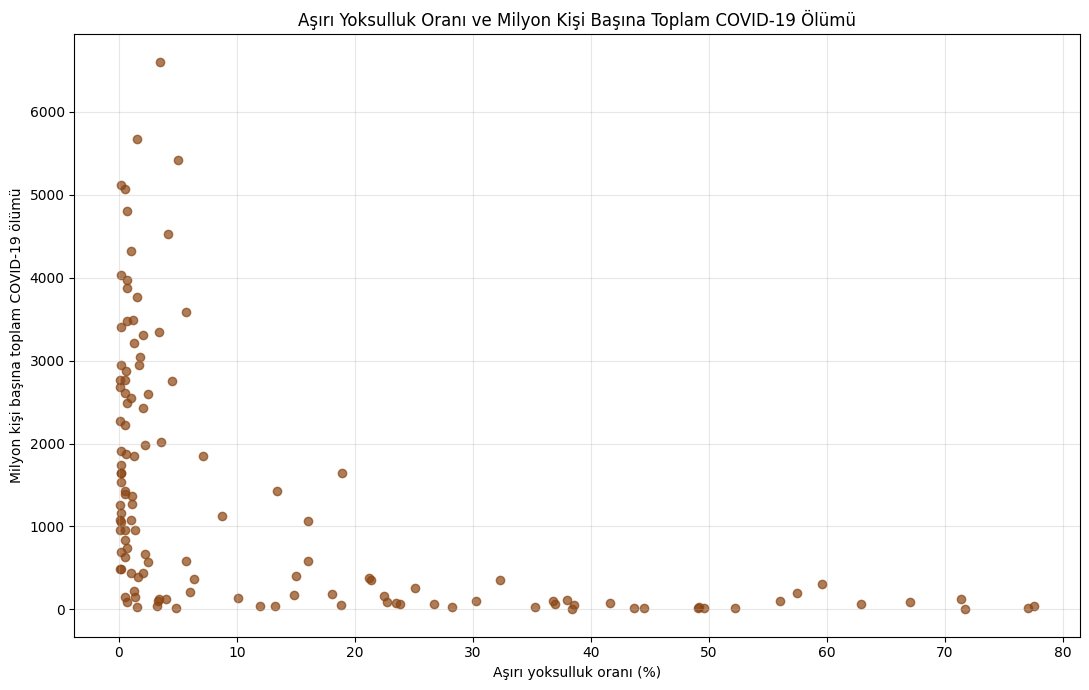

In [211]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    poverty_death_data['extreme_poverty'],
    poverty_death_data['total_deaths_per_million'],
    color='saddlebrown',
    alpha=0.7
)

ax.set_title(
    'Aşırı Yoksulluk Oranı ve Milyon Kişi Başına Toplam COVID-19 Ölümü'
)
ax.set_xlabel('Aşırı yoksulluk oranı (%)')
ax.set_ylabel('Milyon kişi başına toplam COVID-19 ölümü')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [212]:
correlation_poverty_death = (
    poverty_death_data['extreme_poverty']
    .corr(poverty_death_data['total_deaths_per_million'])
)

print(
    'Aşırı yoksulluk oranı ile COVID-19 ölümü korelasyonu:',
    round(correlation_poverty_death, 3)
)

Aşırı yoksulluk oranı ile COVID-19 ölümü korelasyonu: -0.491


In [213]:
smoking_check = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),

        dolu_erkek_sigara_kaydi=('male_smokers', 'count'),
        farkli_erkek_sigara_degeri=(
            'male_smokers',
            'nunique'
        ),
        en_dusuk_erkek_sigara_orani=(
            'male_smokers',
            'min'
        ),
        en_yuksek_erkek_sigara_orani=(
            'male_smokers',
            'max'
        ),

        dolu_kadin_sigara_kaydi=('female_smokers', 'count'),
        farkli_kadin_sigara_degeri=(
            'female_smokers',
            'nunique'
        ),
        en_dusuk_kadin_sigara_orani=(
            'female_smokers',
            'min'
        ),
        en_yuksek_kadin_sigara_orani=(
            'female_smokers',
            'max'
        )
    )
)

smoking_check['bos_erkek_sigara_kaydi'] = (
    smoking_check['toplam_satir']
    - smoking_check['dolu_erkek_sigara_kaydi']
)

smoking_check['bos_kadin_sigara_kaydi'] = (
    smoking_check['toplam_satir']
    - smoking_check['dolu_kadin_sigara_kaydi']
)

print(
    smoking_check
    .sort_values('dolu_erkek_sigara_kaydi')
    .head(20)
)

                                 toplam_satir  dolu_erkek_sigara_kaydi  \
location                                                                 
Afghanistan                              1674                        0   
American Samoa                           1674                        0   
Anguilla                                 1674                        0   
Angola                                   1674                        0   
Antigua and Barbuda                      1674                        0   
Aruba                                    1674                        0   
Bhutan                                   1674                        0   
Bermuda                                  1674                        0   
Bolivia                                  1674                        0   
Belize                                   1674                        0   
British Virgin Islands                   1674                        0   
Bonaire Sint Eustatius and Saba       

In [214]:
valid_smoking_locations = smoking_check[
    (smoking_check['dolu_erkek_sigara_kaydi'] > 0)
    & (smoking_check['dolu_kadin_sigara_kaydi'] > 0)
    & (smoking_check['farkli_erkek_sigara_degeri'] == 1)
    & (smoking_check['farkli_kadin_sigara_degeri'] == 1)
].index

smoking_profile = (
    df_countries[
        df_countries['location'].isin(
            valid_smoking_locations
        )
    ]
    .groupby('location', as_index=False)
    .agg(
        male_smokers=('male_smokers', 'first'),
        female_smokers=('female_smokers', 'first')
    )
)

smoking_death_data = (
    smoking_profile
    .merge(
        df_countries[
            df_countries['date'] == pd.Timestamp('2024-08-04')
        ][
            ['location', 'total_deaths_per_million']
        ],
        on='location',
        how='inner'
    )
    .dropna()
)

print('Karşılaştırılan ülke sayısı:', len(smoking_death_data))
print(smoking_death_data.head())

Karşılaştırılan ülke sayısı: 144
    location  male_smokers  female_smokers  total_deaths_per_million
0    Albania          51.2             7.1                   1274.93
1    Algeria          30.4             0.7                    151.31
2    Andorra          37.8            29.0                   1994.43
3  Argentina          27.7            16.2                   2877.54
4    Armenia          52.1             1.5                   3046.64


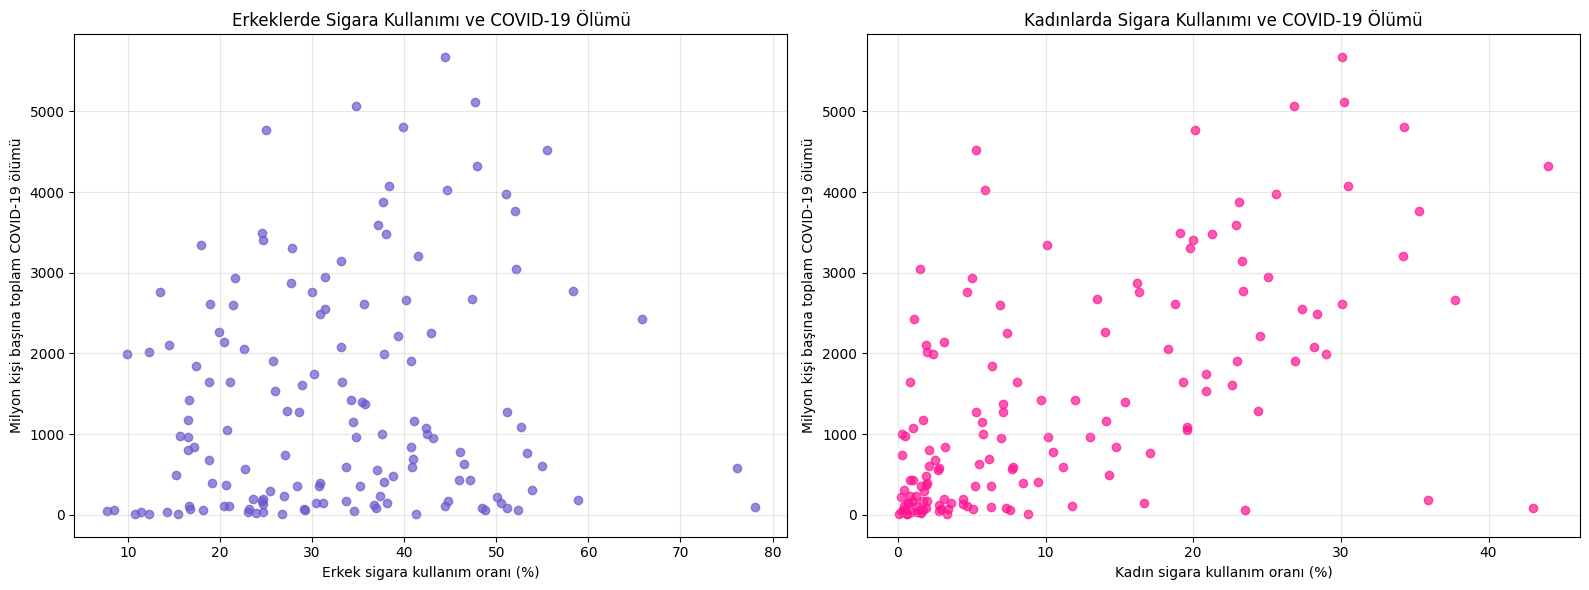

In [215]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Erkek sigara oranı
axes[0].scatter(
    smoking_death_data['male_smokers'],
    smoking_death_data['total_deaths_per_million'],
    color='slateblue',
    alpha=0.7
)

axes[0].set_title(
    'Erkeklerde Sigara Kullanımı ve COVID-19 Ölümü'
)
axes[0].set_xlabel('Erkek sigara kullanım oranı (%)')
axes[0].set_ylabel('Milyon kişi başına toplam COVID-19 ölümü')
axes[0].grid(alpha=0.3)

# Kadın sigara oranı
axes[1].scatter(
    smoking_death_data['female_smokers'],
    smoking_death_data['total_deaths_per_million'],
    color='deeppink',
    alpha=0.7
)

axes[1].set_title(
    'Kadınlarda Sigara Kullanımı ve COVID-19 Ölümü'
)
axes[1].set_xlabel('Kadın sigara kullanım oranı (%)')
axes[1].set_ylabel('Milyon kişi başına toplam COVID-19 ölümü')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [216]:
correlation_male_smoking_death = (
    smoking_death_data['male_smokers']
    .corr(smoking_death_data['total_deaths_per_million'])
)

correlation_female_smoking_death = (
    smoking_death_data['female_smokers']
    .corr(smoking_death_data['total_deaths_per_million'])
)

print(
    'Erkek sigara oranı ile COVID-19 ölümü korelasyonu:',
    round(correlation_male_smoking_death, 3)
)

print(
    'Kadın sigara oranı ile COVID-19 ölümü korelasyonu:',
    round(correlation_female_smoking_death, 3)
)

Erkek sigara oranı ile COVID-19 ölümü korelasyonu: 0.137
Kadın sigara oranı ile COVID-19 ölümü korelasyonu: 0.62


In [217]:
handwashing_check = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),
        dolu_el_yikama_kaydi=(
            'handwashing_facilities',
            'count'
        ),
        farkli_el_yikama_degeri=(
            'handwashing_facilities',
            'nunique'
        ),
        en_dusuk_el_yikama_orani=(
            'handwashing_facilities',
            'min'
        ),
        en_yuksek_el_yikama_orani=(
            'handwashing_facilities',
            'max'
        )
    )
)

handwashing_check['bos_el_yikama_kaydi'] = (
    handwashing_check['toplam_satir']
    - handwashing_check['dolu_el_yikama_kaydi']
)

print(
    handwashing_check
    .sort_values('dolu_el_yikama_kaydi')
    .head(20)
)

                                 toplam_satir  dolu_el_yikama_kaydi  \
location                                                              
Albania                                  1674                     0   
American Samoa                           1674                     0   
Anguilla                                 1674                     0   
Andorra                                  1674                     0   
Antigua and Barbuda                      1674                     0   
Australia                                1674                     0   
Aruba                                    1674                     0   
Argentina                                1678                     0   
Bahrain                                  1674                     0   
Bahamas                                  1674                     0   
Austria                                  1674                     0   
Brazil                                   1674                     0   
Brunei

In [218]:
valid_handwashing_locations = handwashing_check[
    (handwashing_check['dolu_el_yikama_kaydi'] > 0)
    & (handwashing_check['farkli_el_yikama_degeri'] == 1)
    & (handwashing_check['en_dusuk_el_yikama_orani'] >= 0)
].index

handwashing_profile = (
    df_countries[
        df_countries['location'].isin(
            valid_handwashing_locations
        )
    ]
    .groupby('location', as_index=False)
    .agg(
        handwashing_facilities=(
            'handwashing_facilities',
            'first'
        )
    )
)

handwashing_death_data = (
    handwashing_profile
    .merge(
        df_countries[
            df_countries['date'] == pd.Timestamp('2024-08-04')
        ][
            ['location', 'total_deaths_per_million']
        ],
        on='location',
        how='inner'
    )
    .dropna()
)

print('Karşılaştırılan ülke sayısı:', len(handwashing_death_data))
print(handwashing_death_data.head())

Karşılaştırılan ülke sayısı: 95
      location  handwashing_facilities  total_deaths_per_million
0  Afghanistan                   37.75                    197.10
1      Algeria                   83.74                    151.31
2       Angola                   26.66                     54.36
3      Armenia                   94.04                   3046.64
4   Azerbaijan                   83.24                   1005.60


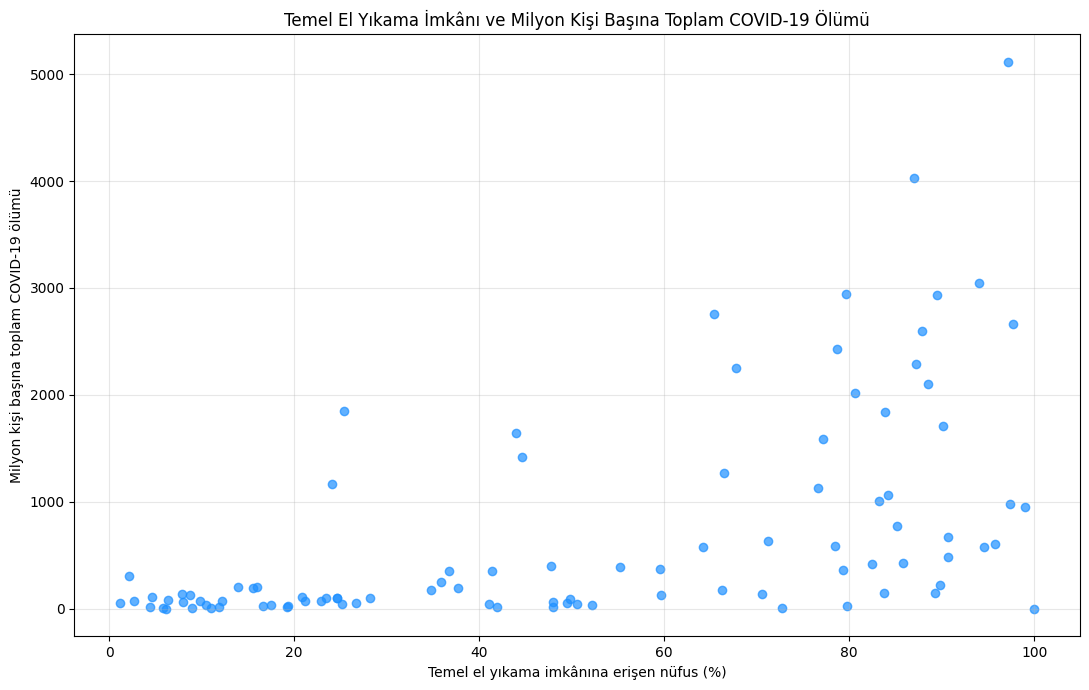

In [219]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    handwashing_death_data['handwashing_facilities'],
    handwashing_death_data['total_deaths_per_million'],
    color='dodgerblue',
    alpha=0.7
)

ax.set_title(
    'Temel El Yıkama İmkânı ve Milyon Kişi Başına Toplam COVID-19 Ölümü'
)
ax.set_xlabel('Temel el yıkama imkânına erişen nüfus (%)')
ax.set_ylabel('Milyon kişi başına toplam COVID-19 ölümü')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [220]:
correlation_handwashing_death = (
    handwashing_death_data['handwashing_facilities']
    .corr(handwashing_death_data['total_deaths_per_million'])
)

print(
    'El yıkama imkânı ile COVID-19 ölümü korelasyonu:',
    round(correlation_handwashing_death, 3)
)

El yıkama imkânı ile COVID-19 ölümü korelasyonu: 0.552


In [221]:
age_70_check = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),
        dolu_70_ustu_kaydi=('aged_70_older', 'count'),
        farkli_70_ustu_degeri=('aged_70_older', 'nunique'),
        en_dusuk_70_ustu_orani=('aged_70_older', 'min'),
        en_yuksek_70_ustu_orani=('aged_70_older', 'max')
    )
)

age_70_check['bos_70_ustu_kaydi'] = (
    age_70_check['toplam_satir']
    - age_70_check['dolu_70_ustu_kaydi']
)

print(
    age_70_check
    .sort_values('dolu_70_ustu_kaydi')
    .head(20)
)

                                 toplam_satir  dolu_70_ustu_kaydi  \
location                                                            
American Samoa                           1674                   0   
Andorra                                  1674                   0   
Anguilla                                 1674                   0   
Bermuda                                  1674                   0   
Bonaire Sint Eustatius and Saba          1674                   0   
British Virgin Islands                   1674                   0   
Cook Islands                             1674                   0   
Cayman Islands                           1674                   0   
Dominica                                 1674                   0   
Jersey                                   1674                   0   
Guernsey                                 1674                   0   
Guadeloupe                               1674                   0   
Gibraltar                         

In [222]:
valid_age_70_locations = age_70_check[
    (age_70_check['dolu_70_ustu_kaydi'] > 0)
    & (age_70_check['farkli_70_ustu_degeri'] == 1)
    & (age_70_check['en_dusuk_70_ustu_orani'] >= 0)
].index

age_70_profile = (
    df_countries[
        df_countries['location'].isin(
            valid_age_70_locations
        )
    ]
    .groupby('location', as_index=False)
    .agg(
        aged_70_older=('aged_70_older', 'first')
    )
)

age_70_death_data = (
    age_70_profile
    .merge(
        df_countries[
            df_countries['date'] == pd.Timestamp('2024-08-04')
        ][
            ['location', 'total_deaths_per_million']
        ],
        on='location',
        how='inner'
    )
    .dropna()
)

print('Karşılaştırılan ülke sayısı:', len(age_70_death_data))
print(age_70_death_data.head())

Karşılaştırılan ülke sayısı: 194
              location  aged_70_older  total_deaths_per_million
0          Afghanistan           1.34                    197.10
1              Albania           8.64                   1274.93
2              Algeria           3.86                    151.31
3               Angola           1.36                     54.36
4  Antigua and Barbuda           4.63                   1572.41


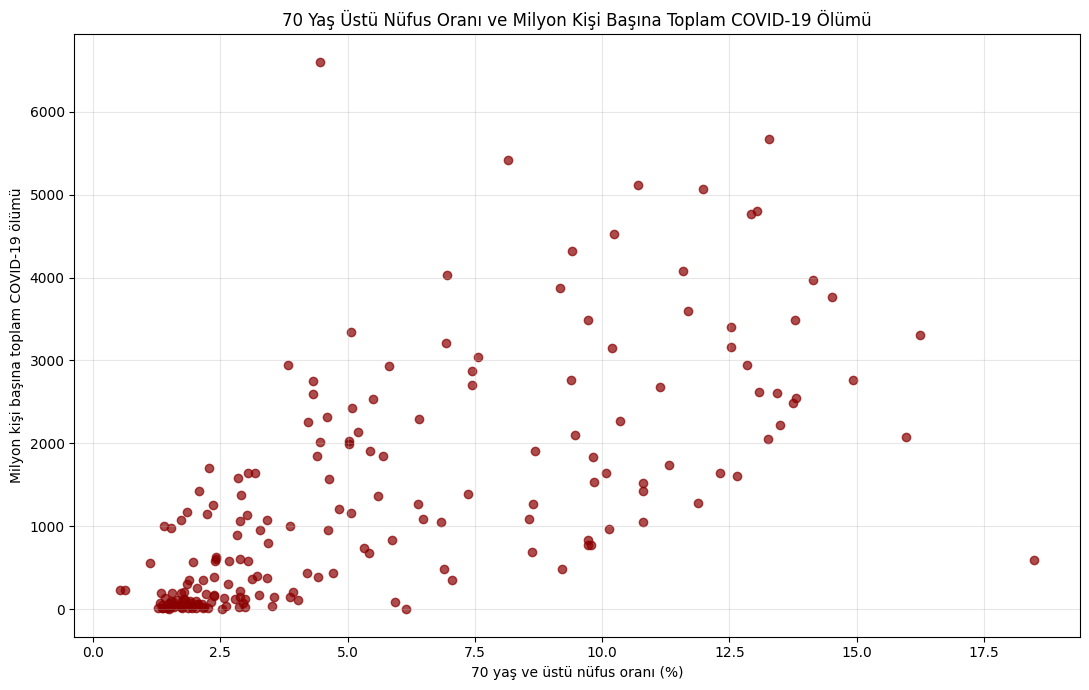

In [223]:
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    age_70_death_data['aged_70_older'],
    age_70_death_data['total_deaths_per_million'],
    color='darkred',
    alpha=0.7
)

ax.set_title(
    '70 Yaş Üstü Nüfus Oranı ve Milyon Kişi Başına Toplam COVID-19 Ölümü'
)
ax.set_xlabel('70 yaş ve üstü nüfus oranı (%)')
ax.set_ylabel('Milyon kişi başına toplam COVID-19 ölümü')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [224]:
correlation_70_death = (
    age_70_death_data['aged_70_older']
    .corr(age_70_death_data['total_deaths_per_million'])
)

print(
    '70 yaş üstü nüfus oranı ile COVID-19 ölümü korelasyonu:',
    round(correlation_70_death, 3)
)

70 yaş üstü nüfus oranı ile COVID-19 ölümü korelasyonu: 0.674
